<a href="https://colab.research.google.com/github/sauraviitj/neural-networks-zero-to-hero/blob/main/2%20%2C%203%2C%204%20Makemore/makemore_part3_bn_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# makemore: part 3 Activations, Gradients and BatchNorm

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


 (5/3)/((n_embd * block_size)**0.5) is Kaiming init
 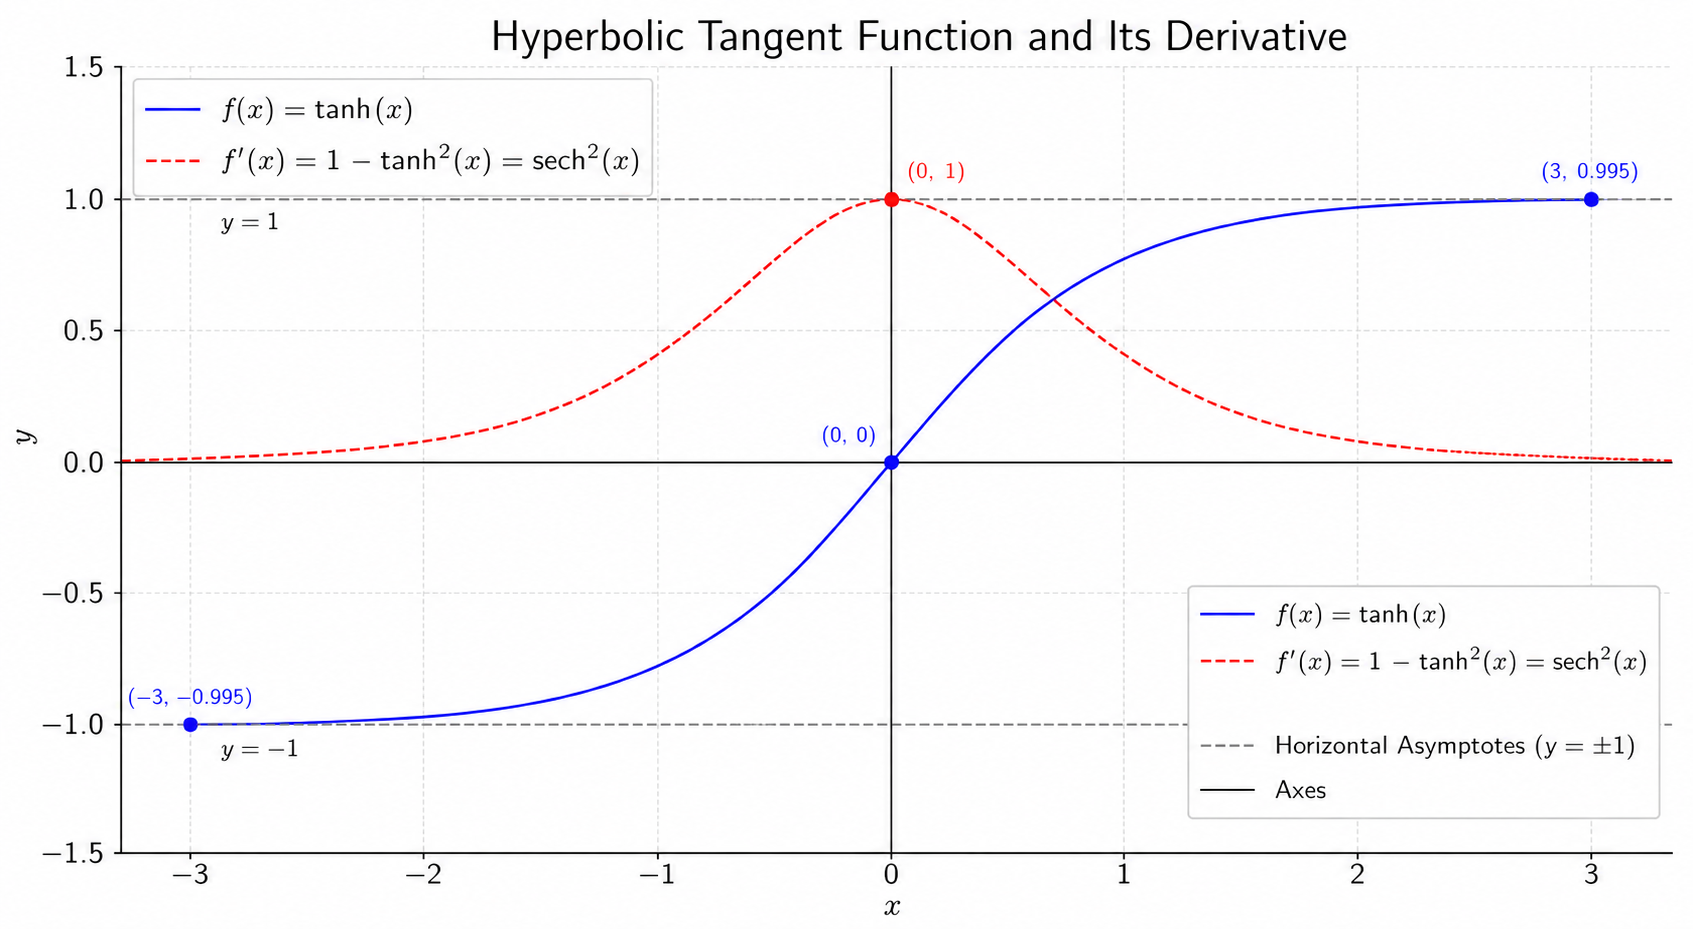

`The tanh function squashes any input into the range (-1, 1)`
When |x| is large (say, > 2), tanh(x) ≈ ±1, so the gradient ≈ 0. The neuron is "dead" — no learning happens. This is called saturation.

so we multiply the term `* (5/3)/((n_embd * block_size)**0.5) `  to  W1

##  Kaiming Init
 https://arxiv.org/abs/1502.01852
### The Problem

Each neuron sums 30 weighted inputs:
    h_i = x1*w1 + x2*w2 + ... + x30*w30

If w ~ N(0,1), the sum explodes (std ≈ 5.5).
tanh(-5) ≈ -1, tanh(+5) ≈ +1 → neuron SATURATED because d/dxtanh(5) ≈ 0

Gradient of tanh at saturation:
    d/dx tanh(x) = 1 - tanh²(x) = 1 - 1² = 0

Zero gradient → zero weight update → network doesn't learn. ❌

---

### The Fix

Scale weights down so the sum stays small:
```
    (n_embd * block_size) ** 0.5
    =  (10   *    3     ) ** 0.5
    =       30             ** 0.5
    =     sqrt(30)
    =       5.47
    W1 = randn * (5/3) / sqrt(30)
    #             ^^^     ^^^^^^^^
    #   gain(universal)  1/sqrt(fan_in)
```
- `1/sqrt(30)` → keeps std(h_pre) ≈ 1.0  (neurons near zero → tanh steep → gradient ≠ 0)
- `5/3` → compensates because tanh still compresses std from 1.0 → 0.76.
  In a 5-layer net: 0.76⁵ ≈ 0.25 (signal dies). gain=5/3 keeps std ≈ 1.0 after tanh. ✅

---

### Quick Reference

| Init | std into tanh | After tanh | Result |
|------|--------------|------------|--------|
| randn | 5.5 | ±1 (saturated) | No learning ❌ |
| randn/sqrt(30) | 1.0 | 0.76 | Shrinks in deep nets ⚠️ |
| randn*(5/3)/sqrt(30) | 1.67 | ≈1.0 | Stable ✅ |

Pytorch documentation: https://docs.pytorch.org/docs/2.12/nn.init.html



In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g) # 27*10
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
print(W1.shape)
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # * 0.01 — Makes the initial logits close to zero → all characters roughly equally likely → initial loss ≈ log(27) ≈ 3.29. This avoids the "confidently wrong at start" problem.
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))       # shape (1, 200)
bnbias = torch.zeros((1, n_hidden))      # shape (1, 200)
bnmean_running = torch.zeros((1, n_hidden))  # shape (1, 200)
bnstd_running  = torch.ones((1, n_hidden))   # shape (1, 200)

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

torch.Size([30, 200])
12097


https://sauraviitj.github.io/init_visualizer.html

| Layer       | Problem                                             | Fix                        |
| ----------- | --------------------------------------------------- | -------------------------- |
| W2 (output) | Logits too wide → softmax overconfident → loss ≈ 27 | × 0.01                     |
| W1 (hidden) | hpreact too wide → tanh saturates → gradient = 0    | Kaiming (5/3)/sqrt(fan_in) |

Batch Normalisation paper: https://arxiv.org/pdf/1502.03167

In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) #Xtr.shape(182625, 3) #ix is 32 random integers betweem 0 and 182624
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y, take rows from Xtr and columns from Ytr at those random positions, so we get a random mini batch of 32 examples
  # forward pass
  emb = C[Xb] # embed the characters into vectors. Xb is 32,3 and C is (27,10) . so emb becomes (32, 3,10)
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors , embcat becomes (32,30)
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation, here embcat is (32,30) and w1 is (30,200) which makes hpreact (32,200)
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True) #mean(0) computes the mean across the batch dimension
  bnstdi = hpreact.std(0, keepdim=True)
  #So for each of the 200 hidden neurons:take all 32 values, compute one mean, compute one std
  #That is why bnmeani and bnstdi are (1, 200).
  #If hpreact has shape (32, 200), then: there are 200 neurons each neuron has 32 values, one from each example in the batch
  # So for each neuron, the mean is computed over those 32 values:That is why the result has shape (1, 200).

  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # gamma * normalised value + beta
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani #This is only for test time later. EMA
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi # This is only for test time later. EMA
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function,logits: (32, 27), Yb: (32,)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


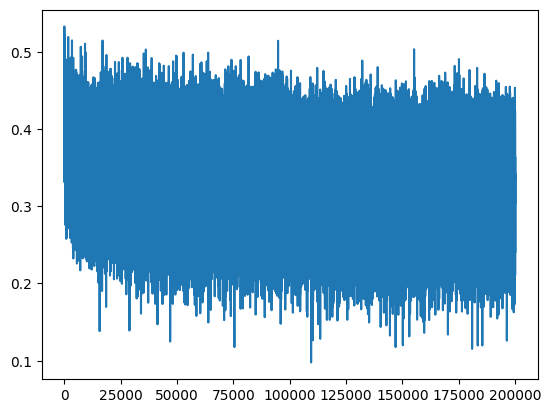

In [8]:
plt.plot(lossi)

In [9]:
# calibrate the batch norm at the end of training why not just compute the exact mean and std using the entire training set at once? That gives much more accurate values for inference.



with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [10]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674147605895996
val 2.1056840419769287


## loss log

### original:
train 2.1245384216308594
val   2.168196439743042

### fix softmax confidently wrong:
train 2.07
val   2.13

### fix tanh layer too saturated at init:
train 2.0355966091156006
val   2.1026785373687744

### use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693
val   2.106989622116089

### add batch norm layer
train 2.0668270587921143
val 2.104844808578491


In [11]:
# SUMMARY + PYTORCHIFYING -----------

https://docs.pytorch.org/docs/2.12/nn.html

```
Linear(fan_in, fan_out)
        ↑        ↑
  30 inputs   100 neurons
```
The second number is always how many neurons that layer has.


In [31]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5 # fan_in= number of inputs, fan_out= number of outputs fan_in**0.5=kaiming init
    self.bias = torch.zeros(fan_out) if bias else None # bias is optional — here most layers use bias=False because BatchNorm already handles the shift

  def __call__(self, x): #It just does x @ W + b.
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim) ## scale — starts at 1
    self.beta = torch.zeros(dim) # shift — starts at 0
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
#This is a 5-layer deep MLP. Each hidden layer has the pattern: Linear → BatchNorm → Tanh
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), #3*10, 100 =(30,100), After the first linear layer, the next layer receives a matrix of shape:(32, 100) and so on
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), #100,100
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),#100,100
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), #100,100
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), #100,100
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size), #finally we get an 32*27 matrix with each member of batch giving its prediction
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]


# ==========================================================
# PREPARING THE NETWORK FOR TRAINING
# ==========================================================

# torch.no_grad():
# We are manually modifying weights before training starts.
# No gradients need to be tracked for these changes.

with torch.no_grad():

    # Make the final layer less confident initially.
    # BatchNorm gamma starts at 1.0, changing it to 0.1
    # reduces the size of output logits.
    # This prevents the network from making overconfident
    # predictions at the beginning of training.
    layers[-1].gamma *= 0.1

    # Adjust hidden layer weight scale if needed.
    # 1.0 means no change.
    # Karpathy sometimes uses 5/3 for Tanh networks.
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0

# ==========================================================
# COLLECT ALL TRAINABLE PARAMETERS
# ==========================================================

# C = embedding matrix
# layer.parameters() returns weights, gamma, beta, etc.
# Combine everything into a single list.

parameters = [C] + [p for layer in layers for p in layer.parameters()]

# Print total number of trainable values in the network.
print(sum(p.nelement() for p in parameters))

# ==========================================================
# ENABLE GRADIENT COMPUTATION
# ==========================================================

# Tell PyTorch to calculate gradients for every parameter
# during backpropagation.

for p in parameters:
    p.requires_grad = True

# Network is now ready for training.

47024


 ##Cross Entropy
```
  x gives a 32 x 27 matrix of model scores.
  For each of the 32 examples, we look at the correct class from y.
  We take the model’s probability for that correct class.
  We compute -log(probability).
So:
  if the model gives a high probability to the true class, the loss is small
  if the model gives a low probability to the true class, the loss is large
  Then we average the 32 individual losses, and that final average is the batch loss.
```

## layer.out.retain_grad()

```
For a tiny network like:

y=x1w1 + x2w2
PyTorch will normally save gradients for:
x1, x2 if they are leaf tensors with requires_grad=True
w1, w2 if they are leaf tensors with requires_grad=True
But it will not save gradients for y1 and y2 if those are intermediate outputs, unless you explicitly ask for them to be retained.
```



In [37]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors C is 27*10 , emb is (32,3,10)
  #print(emb.shape)
  x = emb.view(emb.shape[0], -1) # concatenate the vectors 32*30
  #print(x.shape)
  for layer in layers:
    x = layer(x) # a 32,30 entry neuron is passed to the input size (30, 100): x is 32, 27 tensor which signifies the the output of each batch
  #print(x.shape)

  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph ,By default, PyTorch only populates the .grad attribute for leaf tensors (tensors you created directly, like model weights). It discards gradients for intermediate tensors (like layer outputs) to save memory. Calling .retain_grad() forces PyTorch to keep that gradient.
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2870


This cell is a neural-network health check.
It inspects every Tanh layer and tells us:
- mean activation
- activation spread (std)
- percentage of saturated neurons
- activation histogram

so we can detect exploding activations,
vanishing activations, or Tanh saturation.

layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.78%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.56%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 2.25%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.69%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.88%


Text(0.5, 1.0, 'activation distribution')

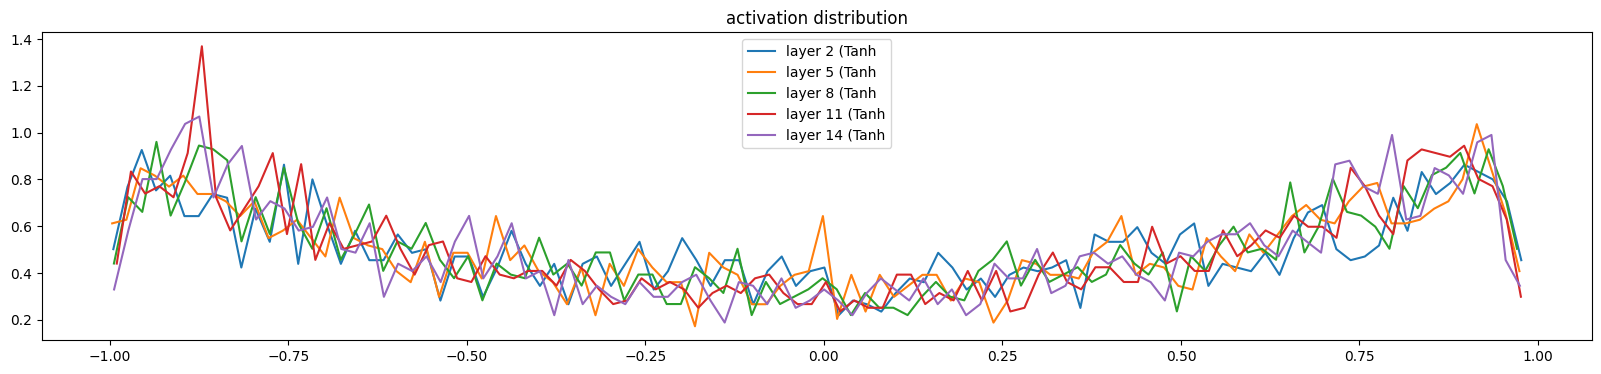

In [38]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')



 layer.out.grad contains the gradient flowing through
each Tanh layer during backpropagation.

This cell helps detect:
1. Vanishing gradients (too small)
2. Exploding gradients (too large)
3. Whether all layers receive similar gradients

Good signs:
- Mean gradient close to 0
- Similar std across layers
- Histogram centered around 0
Bad signs:
- std very close to 0 -> vanishing gradients
- std very large -> exploding gradients

Goal:
Ensure gradients can flow through the entire network
so every layer learns properly.

Activation Histogram:
"Are neurons producing healthy outputs?"

Gradient Histogram:
"Are neurons receiving healthy learning signals?"

layer 2 (      Tanh): mean -0.000000, std 2.640702e-03
layer 5 (      Tanh): mean -0.000000, std 2.245584e-03
layer 8 (      Tanh): mean +0.000000, std 2.045741e-03
layer 11 (      Tanh): mean +0.000000, std 1.983133e-03
layer 14 (      Tanh): mean -0.000000, std 1.952381e-03


Text(0.5, 1.0, 'gradient distribution')

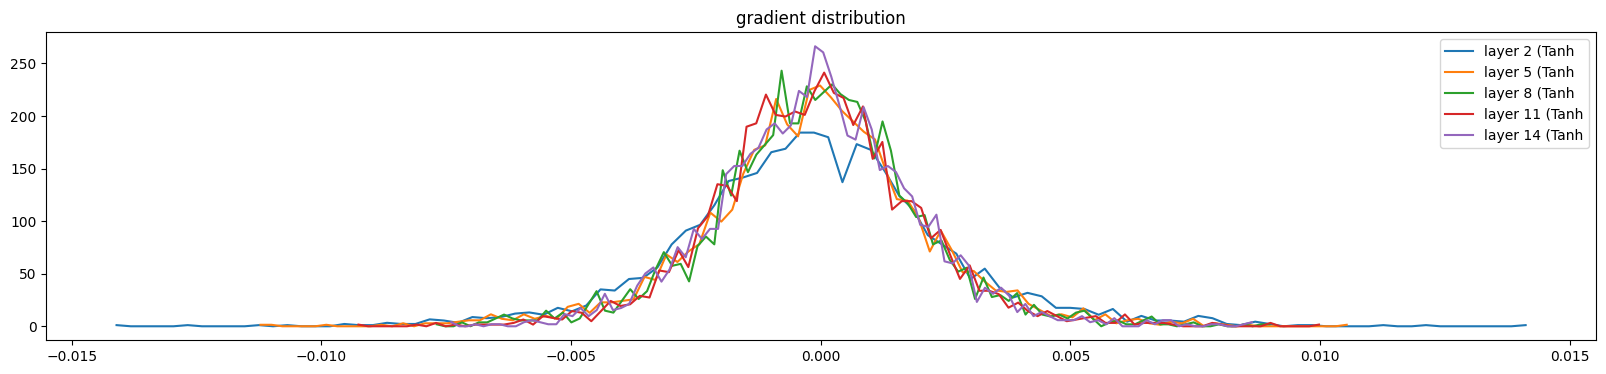

In [39]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 8.020530e-03 | grad:data ratio 8.012626e-03
weight  (30, 100) | mean +0.000246 | std 9.241073e-03 | grad:data ratio 4.881089e-02
weight (100, 100) | mean +0.000113 | std 7.132873e-03 | grad:data ratio 6.964613e-02
weight (100, 100) | mean -0.000086 | std 6.234301e-03 | grad:data ratio 6.073737e-02
weight (100, 100) | mean +0.000052 | std 5.742181e-03 | grad:data ratio 5.631477e-02
weight (100, 100) | mean +0.000032 | std 5.672203e-03 | grad:data ratio 5.570123e-02
weight  (100, 27) | mean -0.000082 | std 1.209415e-02 | grad:data ratio 1.160105e-01


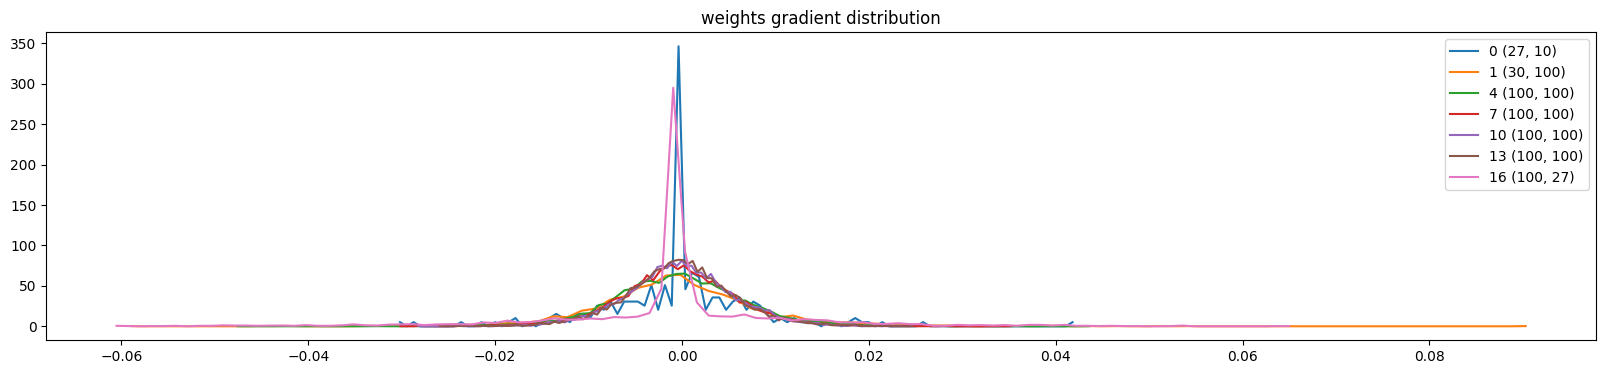

In [40]:
# =====================================================
# WEIGHT GRADIENT DISTRIBUTION CHECK
# =====================================================

# Examines gradients of all weight matrices.
#
# Checks:
# 1. Are gradients centered around 0?
# 2. Are gradients too small (vanishing)?
# 3. Are gradients too large (exploding)?
# 4. Is every layer receiving a similar learning signal?
#
# grad:data ratio = gradient std / weight std
#
# Healthy ratio:
#     ~ 1e-3
#
# Too small:
#     weights barely change
#
# Too large:
#     weights change too aggressively
#
# Goal:
# Ensure all layers learn at a reasonable speed.
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # 2 because there are two parts (x,y
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

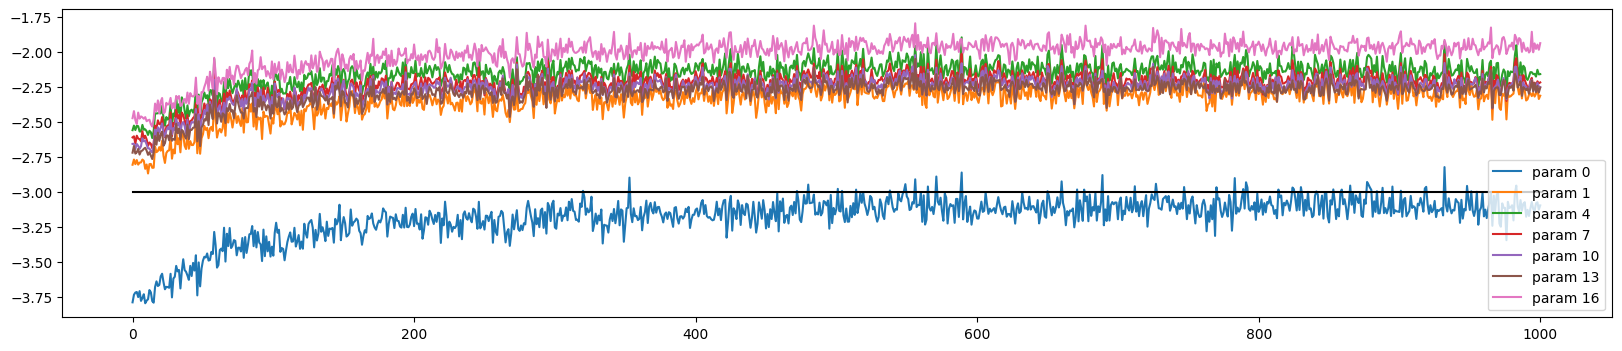

In [41]:
# =====================================================
# UPDATE-TO-DATA RATIO TRACKER
# =====================================================

# Tracks:
#     (lr * gradient std) / (weight std)
#
# Stored in log10 scale.
#
# Target:
#     log10(update/weight) ≈ -3
#
# Meaning:
#     update ≈ 0.1% of weight size
#
# If curve is above -3:
#     updates are too large
#     training may be unstable
#
# If curve is below -3:
#     updates are too small
#     learning may be slow
#
# Goal:
#     Keep all weight matrices near -3
#     throughout training.
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [20]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.4002976417541504
val 2.3982467651367188


In [21]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

carpah.
qarlileif.
jmrix.
thty.
sacansa.
jazhnte.
dpn.
arciigqeiunellaia.
chriiv.
kalein.
dhlm.
join.
qhinn.
sroin.
arian.
quiqaelogiearyxix.
kaeklinsan.
ed.
ecoia.
gtleley.


In [ ]:
# DONE; BONUS content below, not covered in video

In [22]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):

  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));


interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

In [23]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [24]:
# Linear + BatchNorm: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

n = 1000
# linear layer ---
inp = torch.randn(n, requires_grad=True, generator=g)
w = torch.randn((n, n), requires_grad=True, generator=g) # / n**0.5
x = w @ inp
# bn layer ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5)
# ----
loss = out @ torch.randn(n, generator=g)
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()

print('inp std: ', inp.std().item())
print('w std: ', w.std().item())
print('x std: ', x.std().item())
print('out std: ', out.std().item())
print('------')
print('out grad std: ', out.grad.std().item())
print('x grad std: ', x.grad.std().item())
print('w grad std: ', w.grad.std().item())
print('inp grad std: ', inp.grad.std().item())

inp std:  0.9875972270965576
w std:  1.0006722211837769
x std:  31.01241683959961
out std:  1.0
------
out grad std:  0.9782556295394897
x grad std:  0.031543977558612823
w grad std:  0.031169468536973
inp grad std:  0.9953053593635559
